In [1]:
# ============================================================================
# USED MOTORCYCLE MARKET ANALYSIS
# ============================================================================
# Author  : Roshani Ahire
# Dataset : Indian Used Motorcycle Listings
# Goal    : Clean messy real-world data, explore patterns,
#           and build + compare price prediction models
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import warnings

from sklearn.model_selection   import train_test_split, cross_val_score
from sklearn.linear_model      import LinearRegression
from sklearn.ensemble          import RandomForestRegressor
from sklearn.preprocessing     import LabelEncoder
from sklearn.metrics           import (mean_squared_error,
                                       r2_score,
                                       mean_absolute_error)

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [2]:
# ============================================================================
# SECTION 1 — LOAD DATA
# ============================================================================

data = pd.read_csv('/content/Used_Bikes.csv')

print("=" * 80)
print("USED MOTORCYCLE MARKET ANALYSIS")
print("=" * 80)
print(f"\nDataset loaded: {data.shape[0]:,} rows  x  {data.shape[1]} columns\n")

print("First 5 rows:")
print(data.head())

print("\nColumn types and null counts:")
print(data.info())

print("\nMissing values per column:")
print(data.isnull().sum())

print("\nNumeric summary:")
print(data.describe())


USED MOTORCYCLE MARKET ANALYSIS

Dataset loaded: 7,857 rows  x  8 columns

First 5 rows:
                         model_name  model_year      kms_driven        owner  \
0     Bajaj Avenger Cruise 220 2017        2017        17000 Km  first owner   
1  Royal Enfield Classic 350cc 2016        2016        50000 Km  first owner   
2               Hyosung GT250R 2012        2012        14795 Km  first owner   
3        Bajaj Dominar 400 ABS 2017        2017  Mileage 28 Kms  first owner   
4             Jawa Perak 330cc 2020        2020         2000 Km  first owner   

      location       mileage      power   price  
0    hyderabad  \n\n 35 kmpl     19 bhp   63500  
1    hyderabad  \n\n 35 kmpl  19.80 bhp  115000  
2    hyderabad  \n\n 30 kmpl     28 bhp  300000  
3  pondicherry   \n\n 28 Kms  34.50 bhp  100000  
4    bangalore         \n\n      30 bhp  197500  

Column types and null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7857 entries, 0 to 7856
Data columns (total 8 col

In [3]:
# ============================================================================
# SECTION 2 — DATA CLEANING
# ============================================================================

# ----------------------------------------------------------------------------
# 2a  Clean model_name — remove trailing year, extract engine_cc and brand
# ----------------------------------------------------------------------------

# Remove the year that appears at the end of some model names e.g. "... 2017"
data['model_name'] = data['model_name'].str.replace(r'\s\d{4}$', '', regex=True)

# Pull the first number out of the model name — usually the engine size in cc
data['engine_cc'] = data['model_name'].str.extract(r'(\d+)')

# Some model names have no number at all — fill those with a manual lookup
engine_cc_map = {
    'UM Renegade Commando Mojave'           : 279.5,
    'UM Renegade Commando Classic'          : 279,
    'UM Renegade Commando'                  : 196,
    'UM Renegade Sport S'                   : 196.4,
    'Hero Splendor ISmart Self Drum Alloy'  : 97.2,
    'Hero Splendor Plus Special Edition IBS': 97.2,
    'Hero Passion Xpro Drum'               : 109.15,
    'Hero Passion Xpro Disc Self Alloy'    : 109.15,
    'Hero Passion Xpro Disc'               : 109.15,
    'Hero Splendor Plus Black and Accent Edition': 97.2,
    'Hero Splendor Pro Alloy'              : 97.2,
    'TVS Sport Electric Start'             : 109.7,
    'TVS Sport KS LONG SEAT SBT'           : 109.7,
    'TVS Sport KS Spoke'                   : 109.7,
    'TVS Star City Plus Dual Tone SBT'     : 109.7,
    'Kawasaki Vulcan S Black'              : 649,
    'Mahindra Mojo Black Pearl'            : 295,
    'Triumph Thunderbird LT'               : 1600,
    'Ducati Diavel Carbon'                 : 1262,
    'Triumph Tiger Explorer'               : 1215,
    'Harley-Davidson Street Bob'           : 1753,
    'Harley-Davidson Street Rod'           : 1250,
    'Harley-Davidson Fat Bob'              : 1753,
    'Harley-Davidson Fat Boy'              : 1745,
    'Harley-Davidson Superlow'             : 749,
    'Harley-Davidson Forty Eight'          : 1202,
    'Harley-Davidson Breakout'             : 1753,
    'Harley-Davidson Night Rod Special'    : 1250,
    'Harley-Davidson Roadster'             : 1202,
    'Harley-Davidson CVO'                  : 1801,
    'Royal Enfield Interceptor Chrome'     : 650,
    'Royal Enfield Interceptor Custom'     : 650,
    'Triumph Street Triple S'              : 660,
    'Triumph Rocket III Roadster'          : 2294,
}

data['engine_cc'] = data['engine_cc'].fillna(data['model_name'].map(engine_cc_map))

# Extract brand from the start of model_name
# Sort longest first so "Royal Enfield" matches before "Royal"
brands = [
    "Royal Enfield", "Harley-Davidson", "Moto Guzzi", "MV Agusta",
    "FB Mondial", "Benelli Imperiale", "Benelli", "Bajaj", "Aprilia",
    "Yamaha", "Hyosung", "Honda", "Hero", "KTM", "TVS", "Suzuki",
    "Husqvarna", "Mahindra", "Triumph", "BMW", "Ducati", "Kawasaki",
    "UM", "Indian", "Jawa", "Yezdi"
]
brands_sorted = sorted(brands, key=len, reverse=True)

def extract_brand(model):
    for b in brands_sorted:
        if re.match(r'^' + re.escape(b) + r'\b', model.strip(), re.IGNORECASE):
            return b
    return model.strip().split()[0]

data['brand'] = data['model_name'].apply(extract_brand)
data['brand'] = data['brand'].replace({'BenelliImperiale': 'Benelli'})

# Convert engine_cc to numeric, fill any remaining gaps with brand median
data['engine_cc'] = pd.to_numeric(data['engine_cc'], errors='coerce')
data['engine_cc'] = data['engine_cc'].fillna(
    data.groupby('brand')['engine_cc'].transform('median')
)
data['engine_cc'] = data['engine_cc'].fillna(data['engine_cc'].median())


In [4]:
# ----------------------------------------------------------------------------
# 2b  Clean kms_driven
# The column mixes formats: "17000 Km", "28 Kms", and even fuel mileage values
# ----------------------------------------------------------------------------

data['kms_driven'] = data['kms_driven'].astype(str)

# Flag rows where kms_driven actually contains fuel mileage (kmpl)
mileage_mask = data['kms_driven'].str.contains('kmpl', case=False, na=False)

# Pull numeric part from whatever format is present
data['kms_driven'] = data['kms_driven'].str.extract(r'(\d+\.?\d*)')
data['kms_driven'] = pd.to_numeric(data['kms_driven'], errors='coerce')

# Rows flagged as mileage are meaningless here — mark as missing
data.loc[mileage_mask, 'kms_driven'] = np.nan

# Remove clear errors: <100 km (odometer readings like "28" were fuel economy)
# and >500,000 km (data entry mistakes)
data.loc[
    (data['kms_driven'] < 100) | (data['kms_driven'] > 500000),
    'kms_driven'
] = np.nan

# Fill remaining missing values with the median for that brand
data['kms_driven'] = data['kms_driven'].fillna(
    data.groupby('brand')['kms_driven'].transform('median')
)
data['kms_driven'] = data['kms_driven'].fillna(data['kms_driven'].median())


In [5]:
# ----------------------------------------------------------------------------
# 2c  Clean mileage (fuel efficiency in kmpl)
# ----------------------------------------------------------------------------

data['mileage'] = data['mileage'].astype(str).str.strip()
data['mileage'].replace(r'^\s*$', np.nan, regex=True, inplace=True)

# Handle range values like "40-50" — take the midpoint
range_mask = data['mileage'].str.contains(r'\d+\s*-\s*\d+', na=False)
data.loc[range_mask, 'mileage'] = (
    data.loc[range_mask, 'mileage']
    .str.extract(r'(\d+)\s*-\s*(\d+)')
    .astype(float)
    .mean(axis=1)
)

data['mileage'] = data['mileage'].str.extract(r'(\d+\.?\d*)')
data['mileage'] = pd.to_numeric(data['mileage'], errors='coerce')

# Apply brand-specific realistic bounds — a Harley at 70 kmpl is impossible
mileage_bounds = {
    'Hero': (35, 85),   'Bajaj': (35, 85),   'TVS': (35, 85),
    'Honda': (35, 85),  'Yamaha': (30, 70),   'Suzuki': (30, 65),
    'KTM': (20, 45),    'Royal Enfield': (20, 45), 'Jawa': (20, 45),
    'Husqvarna': (25, 50), 'Aprilia': (20, 40), 'UM': (20, 40),
    'Benelli': (15, 35), 'Kawasaki': (15, 35), 'Triumph': (15, 35),
    'Harley-Davidson': (12, 30), 'BMW': (15, 35), 'Ducati': (12, 30),
    'Moto Guzzi': (12, 30), 'MV Agusta': (12, 30), 'Indian': (10, 25),
    'Hyosung': (20, 40), 'FB Mondial': (20, 40), 'Mahindra': (30, 60),
    'Yezdi': (30, 60),
}
for brand, (lo, hi) in mileage_bounds.items():
    data.loc[
        (data['brand'] == brand) &
        ((data['mileage'] < lo) | (data['mileage'] > hi)),
        'mileage'
    ] = np.nan

data['mileage'] = data['mileage'].fillna(
    data.groupby('brand')['mileage'].transform('median')
)
data['mileage'] = data['mileage'].fillna(data['mileage'].median())


In [6]:
# ----------------------------------------------------------------------------
# 2d  Clean power
# ----------------------------------------------------------------------------

data['power'] = pd.to_numeric(
    data['power'].astype(str).str.extract(r'(\d+\.?\d*)')[0],
    errors='coerce'
)
data['power'] = data['power'].fillna(
    data.groupby('brand')['power'].transform('median')
)
data['power'] = data['power'].fillna(data['power'].median())


In [7]:
# ----------------------------------------------------------------------------
# 2e  Encode owner
# ----------------------------------------------------------------------------

data['owner'] = data['owner'].str.strip().str.title()
owner_map = {
    'First Owner': 1, 'Second Owner': 2,
    'Third Owner': 3, 'Fourth Owner Or More': 4,
    'Fourth & Above Owner': 4
}
data['owner_num'] = data['owner'].map(owner_map)


In [8]:
# ----------------------------------------------------------------------------
# 2f  Standardise location
# ----------------------------------------------------------------------------

data['location'] = data['location'].str.title().fillna('Unknown')
data['location'] = data['location'].replace({
    'Bangalore': 'Bengaluru', 'Trivandrum': 'Thiruvananthapuram',
    'Bhatinda': 'Bathinda',   'Murad Nagar': 'Muradnagar',
    'Chinchwad': 'Pimpri Chinchwad', 'Hamirpur(Hp)': 'Hamirpur',
    'Goa-Panaji': 'Panaji',   'Sonepat': 'Sonipat',
})

print(f"\nCleaning complete. Final shape: {data.shape}")
print(f"Total missing values remaining: {data.isnull().sum().sum()}")



Cleaning complete. Final shape: (7857, 11)
Total missing values remaining: 0


In [9]:
# ============================================================================
# SECTION 3 — FEATURE ENGINEERING
# ============================================================================

# How old the bike is — more useful than raw model year for depreciation
data['bike_age'] = 2021 - data['model_year']

# Value metric: price relative to engine size
data['price_per_cc'] = data['price'] / data['engine_cc']

# Segment the market into three tiers
premium_brands   = ['Harley-Davidson', 'Ducati', 'BMW', 'Triumph', 'Kawasaki',
                    'MV Agusta', 'Aprilia', 'Moto Guzzi', 'Indian']
mid_range_brands = ['Royal Enfield', 'KTM', 'Benelli', 'Jawa',
                    'Hyosung', 'UM', 'Husqvarna']

def categorize_brand(brand):
    if brand in premium_brands:   return 'Premium'
    if brand in mid_range_brands: return 'Mid-Range'
    return 'Economy'

data['brand_category'] = data['brand'].apply(categorize_brand)

print("\nFeature engineering complete.")
print(data[['bike_age', 'price_per_cc', 'brand_category']].head())



Feature engineering complete.
   bike_age  price_per_cc brand_category
0         4    288.636364        Economy
1         5    328.571429      Mid-Range
2         9   1200.000000      Mid-Range
3         4    250.000000        Economy
4         1    598.484848      Mid-Range



EXPLORATORY DATA ANALYSIS


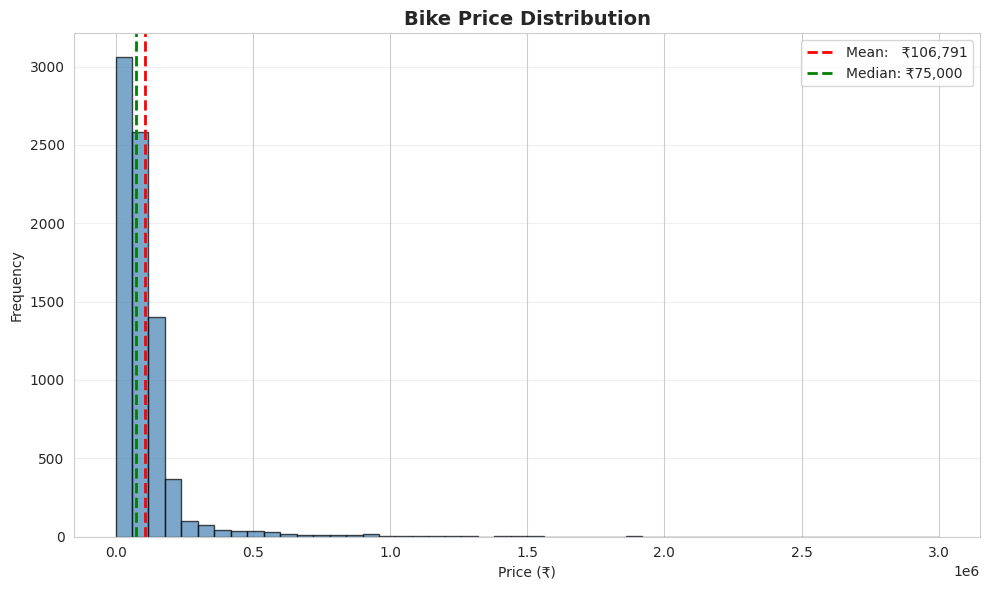

In [10]:
# ============================================================================
# SECTION 4 — EXPLORATORY DATA ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 80)

# ── Chart 1: Price Distribution ──────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.hist(data['price'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(data['price'].mean(),   color='red',   linestyle='--', lw=2,
            label=f"Mean:   ₹{data['price'].mean():,.0f}")
plt.axvline(data['price'].median(), color='green', linestyle='--', lw=2,
            label=f"Median: ₹{data['price'].median():,.0f}")
plt.xlabel('Price (₹)');  plt.ylabel('Frequency')
plt.title('Bike Price Distribution', fontsize=14, fontweight='bold')
plt.legend(); plt.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.savefig('chart1_price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


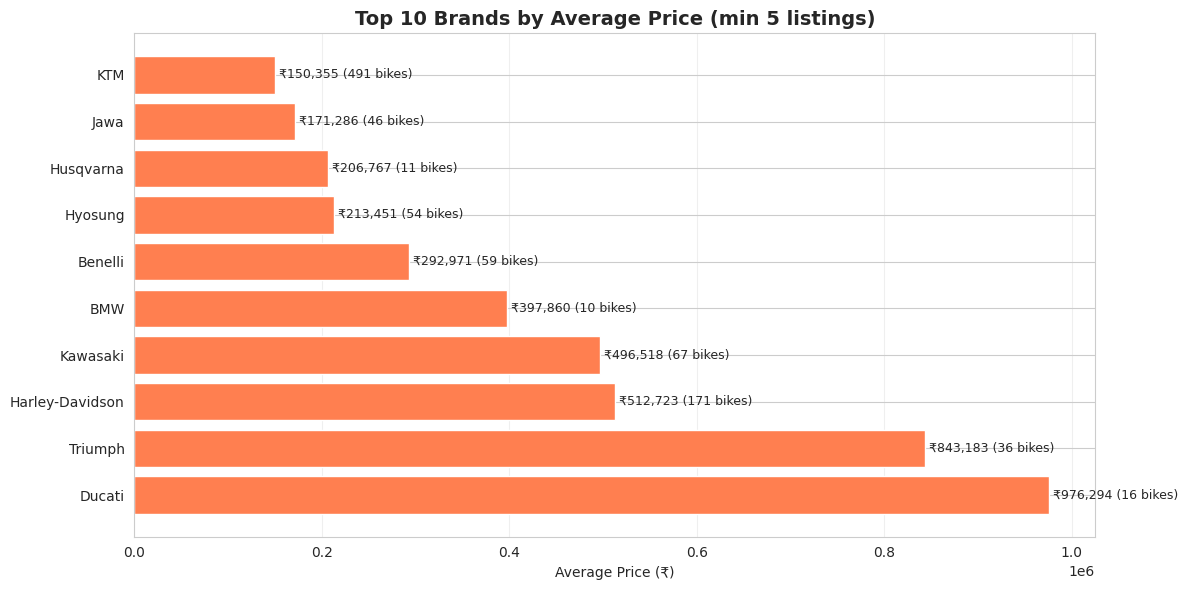

In [11]:
# ── Chart 2: Top 10 Brands by Average Price ───────────────────────────────────
top_brands = (data.groupby('brand')
                  .agg(avg_price=('price', 'mean'), count=('model_name', 'count'))
                  .query('count >= 5')
                  .sort_values('avg_price', ascending=False)
                  .head(10))

plt.figure(figsize=(12, 6))
plt.barh(range(len(top_brands)), top_brands['avg_price'], color='coral')
plt.yticks(range(len(top_brands)), top_brands.index)
plt.xlabel('Average Price (₹)')
plt.title('Top 10 Brands by Average Price (min 5 listings)',
          fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
for i, (_, row) in enumerate(top_brands.iterrows()):
    plt.text(row['avg_price'], i,
             f" ₹{row['avg_price']:,.0f} ({int(row['count'])} bikes)",
             va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart2_top_brands.png', dpi=300, bbox_inches='tight')
plt.show()

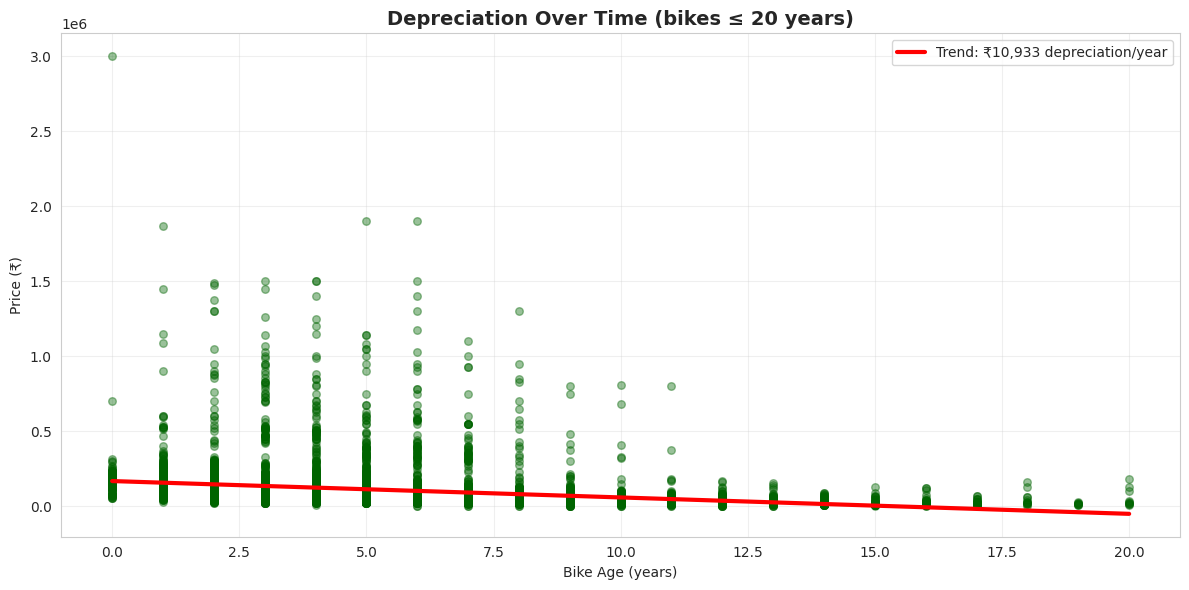

Average annual depreciation: ₹10,933


In [12]:
# ── Chart 3: Depreciation Pattern ────────────────────────────────────────────
recent = data[data['bike_age'] <= 20]
z      = np.polyfit(recent['bike_age'], recent['price'], 1)
p_line = np.poly1d(z)

plt.figure(figsize=(12, 6))
plt.scatter(recent['bike_age'], recent['price'], alpha=0.4, s=30, color='darkgreen')
ages = sorted(recent['bike_age'].unique())
plt.plot(ages, p_line(ages), 'r-', lw=3,
         label=f'Trend: ₹{-z[0]:,.0f} depreciation/year')
plt.xlabel('Bike Age (years)'); plt.ylabel('Price (₹)')
plt.title('Depreciation Over Time (bikes ≤ 20 years)',
          fontsize=14, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('chart3_depreciation.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Average annual depreciation: ₹{-z[0]:,.0f}")


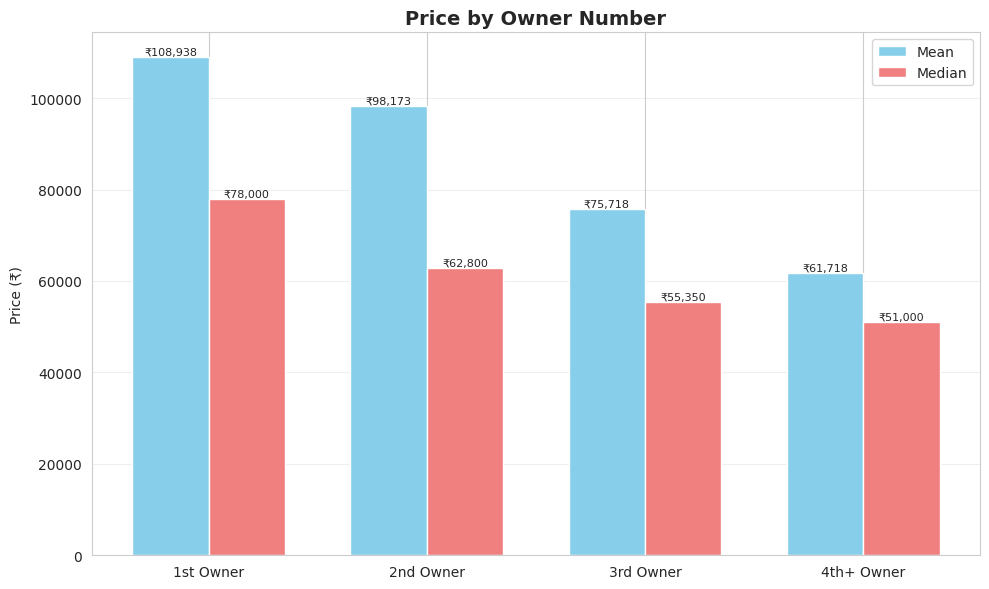

First-owner premium: 19.5%


In [13]:
# ── Chart 4: Owner Impact ─────────────────────────────────────────────────────
owner_stats = data.groupby('owner_num')['price'].agg(['mean', 'median', 'count'])
labels      = ['1st Owner', '2nd Owner', '3rd Owner', '4th+ Owner']
x_pos       = np.arange(len(labels))
w           = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x_pos - w/2, owner_stats['mean'],   w, label='Mean',   color='skyblue')
b2 = ax.bar(x_pos + w/2, owner_stats['median'], w, label='Median', color='lightcoral')
ax.set_xticks(x_pos); ax.set_xticklabels(labels)
ax.set_ylabel('Price (₹)'); ax.set_title('Price by Owner Number',
                                          fontsize=14, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h,
                f'₹{h:,.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('chart4_owner_impact.png', dpi=300, bbox_inches='tight')
plt.show()

first_med  = owner_stats.loc[1, 'median']
second_med = owner_stats.loc[2, 'median']
print(f"First-owner premium: {(first_med - second_med)/first_med*100:.1f}%")


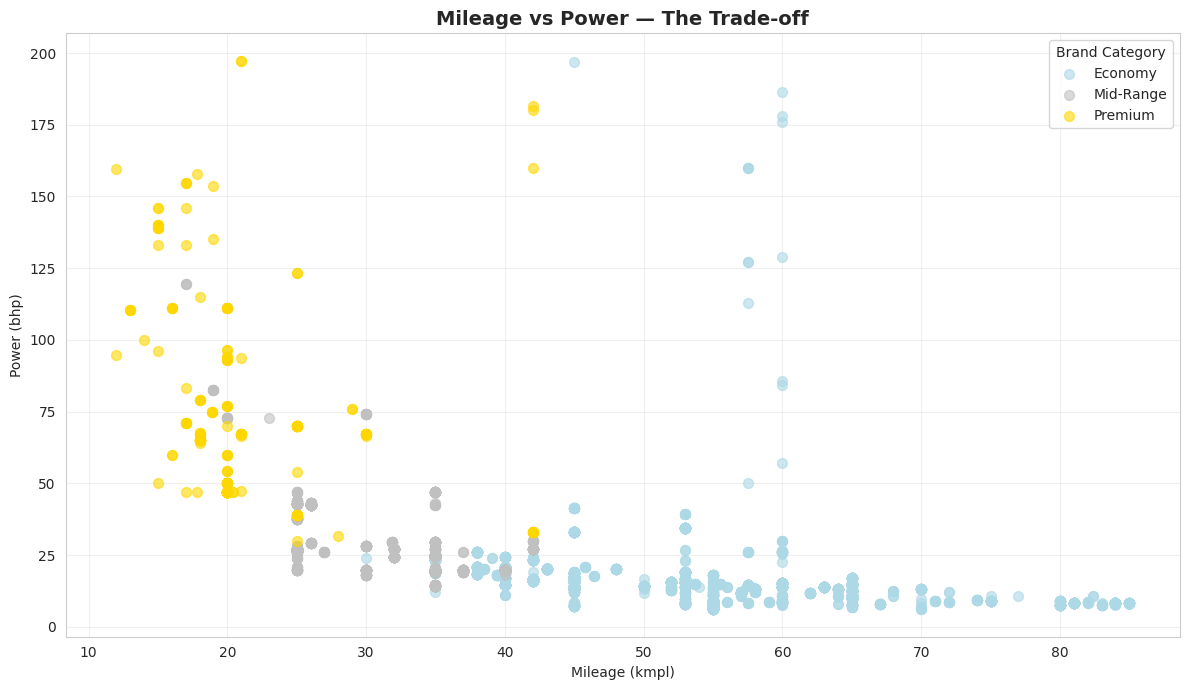

Mileage-Power correlation: -0.55


In [14]:
# ── Chart 5: Mileage vs Power ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
colors  = {'Premium': 'gold', 'Mid-Range': 'silver', 'Economy': 'lightblue'}
for cat, grp in data.groupby('brand_category'):
    ax.scatter(grp['mileage'], grp['power'],
               label=cat, alpha=0.6, s=50, color=colors[cat])
ax.set_xlabel('Mileage (kmpl)'); ax.set_ylabel('Power (bhp)')
ax.set_title('Mileage vs Power — The Trade-off',
             fontsize=14, fontweight='bold')
ax.legend(title='Brand Category'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart5_mileage_power.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Mileage-Power correlation: {data['mileage'].corr(data['power']):.2f}")


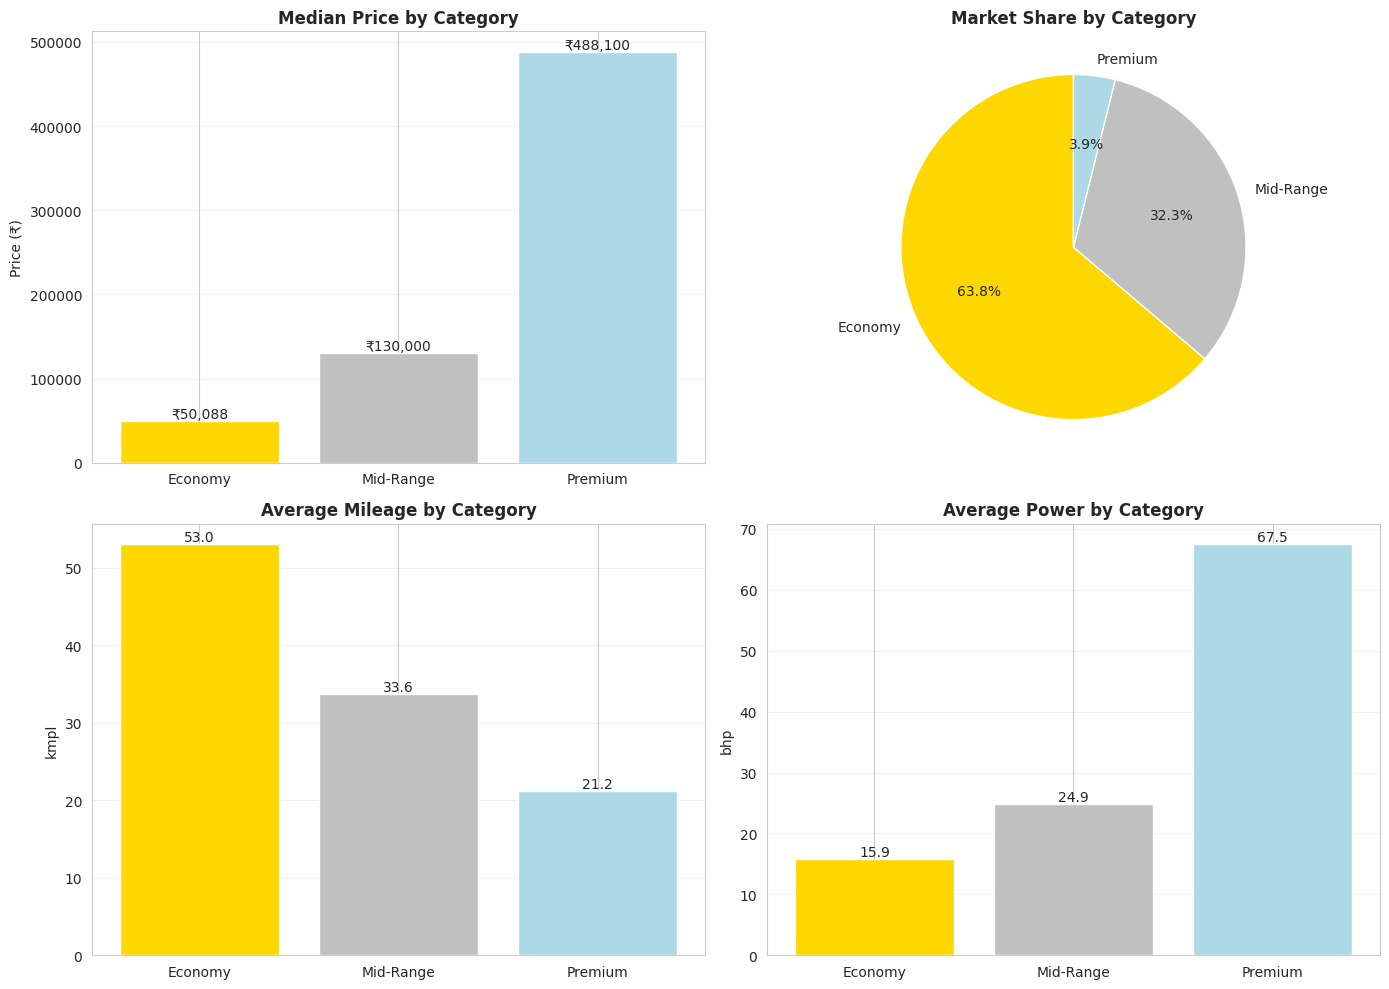

In [15]:
# ── Chart 6: Brand Category Comparison ───────────────────────────────────────
cat_stats = data.groupby('brand_category').agg(
    price   = ('price', 'median'),
    mileage = ('mileage', 'mean'),
    power   = ('power', 'mean'),
    count   = ('model_name', 'count')
)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cat_colors = ['gold', 'silver', 'lightblue']

axes[0, 0].bar(cat_stats.index, cat_stats['price'], color=cat_colors)
axes[0, 0].set_title('Median Price by Category', fontweight='bold')
axes[0, 0].set_ylabel('Price (₹)'); axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(cat_stats['price']):
    axes[0, 0].text(i, v, f'₹{v:,.0f}', ha='center', va='bottom')

axes[0, 1].pie(cat_stats['count'], labels=cat_stats.index,
               autopct='%1.1f%%', colors=cat_colors, startangle=90)
axes[0, 1].set_title('Market Share by Category', fontweight='bold')

axes[1, 0].bar(cat_stats.index, cat_stats['mileage'], color=cat_colors)
axes[1, 0].set_title('Average Mileage by Category', fontweight='bold')
axes[1, 0].set_ylabel('kmpl'); axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(cat_stats['mileage']):
    axes[1, 0].text(i, v, f'{v:.1f}', ha='center', va='bottom')

axes[1, 1].bar(cat_stats.index, cat_stats['power'], color=cat_colors)
axes[1, 1].set_title('Average Power by Category', fontweight='bold')
axes[1, 1].set_ylabel('bhp'); axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(cat_stats['power']):
    axes[1, 1].text(i, v, f'{v:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('chart6_category_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# ============================================================================
# SECTION 5 — PREPARE SHARED FEATURE SET FOR MODELLING
#
# Both models use the same features and the same train/test split —
# the only way to make a fair comparison is to keep everything else constant
# ============================================================================

print("\n" + "=" * 80)
print("PREPARING DATA FOR MODELLING")
print("=" * 80)

# Label-encode brand and category so Random Forest can use them
le_brand    = LabelEncoder()
le_category = LabelEncoder()
data['brand_encoded']    = le_brand.fit_transform(data['brand'])
data['category_encoded'] = le_category.fit_transform(data['brand_category'])

FEATURES = [
    'bike_age',
    'kms_driven',
    'engine_cc',
    'power',
    'mileage',
    'owner_num',
    'brand_encoded',
    'category_encoded',
]
TARGET = 'price'

model_data = data[FEATURES + [TARGET]].dropna()
X = model_data[FEATURES]
y = model_data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {len(X_train):,} rows")
print(f"Test set     : {len(X_test):,} rows")
print(f"Features     : {FEATURES}")



PREPARING DATA FOR MODELLING
Training set : 6,285 rows
Test set     : 1,572 rows
Features     : ['bike_age', 'kms_driven', 'engine_cc', 'power', 'mileage', 'owner_num', 'brand_encoded', 'category_encoded']



MODEL 1: LINEAR REGRESSION (BASELINE)

R²   : 0.559   → explains 55.9% of price variation
RMSE : ₹96,963
MAE  : ₹36,899   → typical prediction is off by this much
MAPE : 51.2%

Linear Regression — feature coefficients:
  category_encoded    : increases price by ₹23,746.39 per unit
  owner_num           : decreases price by ₹9,786.28 per unit
  power               : increases price by ₹5,932.85 per unit
  bike_age            : decreases price by ₹3,783.61 per unit
  mileage             : increases price by ₹1,378.28 per unit
  brand_encoded       : increases price by ₹670.82 per unit
  engine_cc           : increases price by ₹189.89 per unit
  kms_driven          : decreases price by ₹0.24 per unit


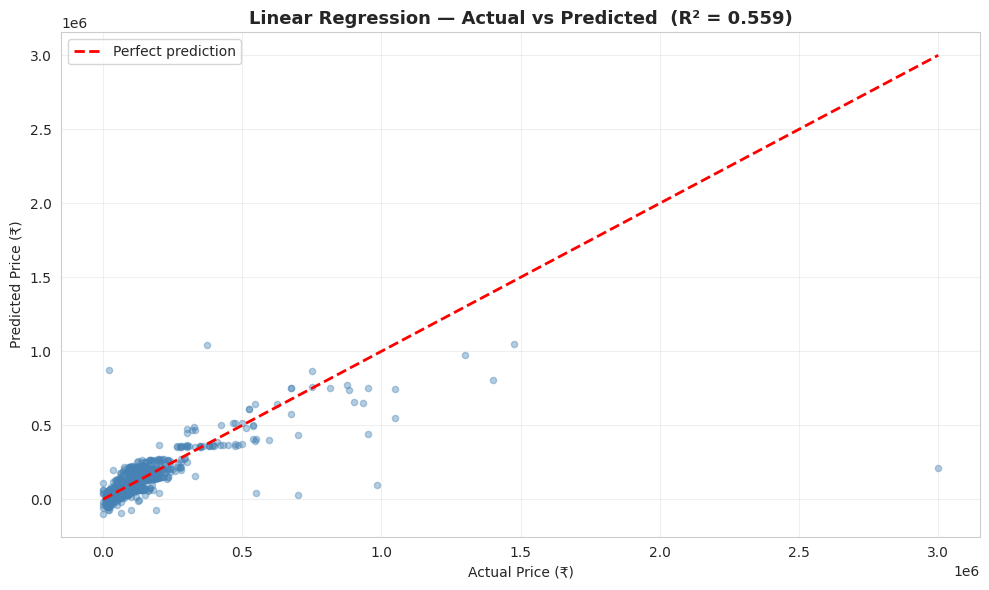


Baseline set. R² = 0.559, MAE = ₹36,899
Now let's see if a Random Forest can do better on the same data.


In [17]:
# ============================================================================
# SECTION 6 — MODEL 1: LINEAR REGRESSION
# A simple baseline — assumes a straight-line relationship between
# each feature and price.  Good starting point, easy to interpret.
# ============================================================================

print("\n" + "=" * 80)
print("MODEL 1: LINEAR REGRESSION (BASELINE)")
print("=" * 80)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred  = lr_model.predict(X_test)

lr_r2   = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae  = mean_absolute_error(y_test, lr_pred)

nonzero  = y_test != 0
lr_mape  = np.mean(np.abs(
    (y_test[nonzero] - lr_pred[nonzero]) / y_test[nonzero]
)) * 100

print(f"\nR²   : {lr_r2:.3f}   → explains {lr_r2*100:.1f}% of price variation")
print(f"RMSE : ₹{lr_rmse:,.0f}")
print(f"MAE  : ₹{lr_mae:,.0f}   → typical prediction is off by this much")
print(f"MAPE : {lr_mape:.1f}%")

# Coefficients — how much each feature moves price per unit
coef_df = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nLinear Regression — feature coefficients:")
for _, row in coef_df.iterrows():
    direction = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"  {row['Feature']:20s}: {direction} price by "
          f"₹{abs(row['Coefficient']):,.2f} per unit")

# Quick scatter: actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, lr_pred, alpha=0.4, s=20, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Price (₹)'); plt.ylabel('Predicted Price (₹)')
plt.title(f'Linear Regression — Actual vs Predicted  (R² = {lr_r2:.3f})',
          fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('lr_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nBaseline set. R² = {lr_r2:.3f}, MAE = ₹{lr_mae:,.0f}")
print("Now let's see if a Random Forest can do better on the same data.")


In [18]:
# ============================================================================
# SECTION 7 — MODEL 2: RANDOM FOREST
#
# Random Forest builds many decision trees on random subsets of data and
# features, then averages their predictions. It handles non-linear patterns
# that Linear Regression misses — e.g. the steep depreciation in year 1-3
# vs the flatter curve after year 5.
# ============================================================================

print("\n" + "=" * 80)
print("MODEL 2: RANDOM FOREST")
print("=" * 80)

rf_model = RandomForestRegressor(
    n_estimators     = 200,   # 200 trees — enough for stability on 7k rows
    max_depth        = 15,    # limit depth to avoid memorising training noise
    min_samples_split= 5,     # a node needs 5+ samples before it can split
    min_samples_leaf = 2,     # every leaf needs at least 2 samples
    random_state     = 42,    # reproducible results
    n_jobs           = -1     # use all CPU cores
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_r2   = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_mape = np.mean(np.abs(
    (y_test[nonzero] - rf_pred[nonzero]) / y_test[nonzero]
)) * 100

# Cross-validation: evaluate on 5 different splits to get a reliable estimate
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2', n_jobs=-1)

print(f"\nR²   : {rf_r2:.3f}   → explains {rf_r2*100:.1f}% of price variation")
print(f"RMSE : ₹{rf_rmse:,.0f}")
print(f"MAE  : ₹{rf_mae:,.0f}")
print(f"MAPE : {rf_mape:.1f}%")
print(f"CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}  (5-fold)")



MODEL 2: RANDOM FOREST

R²   : 0.665   → explains 66.5% of price variation
RMSE : ₹84,462
MAE  : ₹18,092
MAPE : 20.4%
CV R²: 0.827 ± 0.071  (5-fold)


In [19]:
# ============================================================================
# SECTION 8 — MODEL COMPARISON
# ============================================================================

print("\n" + "=" * 80)
print("MODEL COMPARISON: LINEAR REGRESSION  vs  RANDOM FOREST")
print("=" * 80)

print(f"\n  {'Metric':<20} {'Linear Regression':>20} {'Random Forest':>20}")
print(f"  {'-'*62}")
print(f"  {'R² Score':<20} {lr_r2:>20.3f} {rf_r2:>20.3f}")
print(f"  {'RMSE (₹)':<20} {lr_rmse:>20,.0f} {rf_rmse:>20,.0f}")
print(f"  {'MAE (₹)':<20} {lr_mae:>20,.0f} {rf_mae:>20,.0f}")
print(f"  {'MAPE (%)':<20} {lr_mape:>20.1f} {rf_mape:>20.1f}")
print(f"  {'CV R²':<20} {'—':>20} {cv_scores.mean():>20.3f}")
print(f"  {'='*62}")

r2_gain   = (rf_r2  - lr_r2)  / lr_r2  * 100
mae_drop  = (lr_mae - rf_mae)  / lr_mae * 100
mape_drop =  lr_mape - rf_mape

print(f"\n  R² improved by  : +{r2_gain:.1f}%")
print(f"  MAE reduced by  : -{mae_drop:.1f}%  (₹{lr_mae - rf_mae:,.0f} less per prediction)")
print(f"  MAPE reduced by : -{mape_drop:.1f} percentage points")



MODEL COMPARISON: LINEAR REGRESSION  vs  RANDOM FOREST

  Metric                  Linear Regression        Random Forest
  --------------------------------------------------------------
  R² Score                            0.559                0.665
  RMSE (₹)                           96,963               84,462
  MAE (₹)                            36,899               18,092
  MAPE (%)                             51.2                 20.4
  CV R²                                   —                0.827

  R² improved by  : +19.1%
  MAE reduced by  : -51.0%  (₹18,808 less per prediction)
  MAPE reduced by : -30.7 percentage points


In [20]:
# ============================================================================
# SECTION 9 — FEATURE IMPORTANCE (Random Forest)
# ============================================================================

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE — RANDOM FOREST")
print("=" * 80)

importance_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n  {'Feature':<22} {'Score':>8}   Bar")
print(f"  {'-'*55}")
for _, row in importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 100)
    print(f"  {row['Feature']:<22} {row['Importance']:>8.4f}   {bar}")



FEATURE IMPORTANCE — RANDOM FOREST

  Feature                   Score   Bar
  -------------------------------------------------------
  power                    0.7480   ██████████████████████████████████████████████████████████████████████████
  engine_cc                0.0966   █████████
  bike_age                 0.0522   █████
  category_encoded         0.0455   ████
  kms_driven               0.0305   ███
  mileage                  0.0171   █
  brand_encoded            0.0086   
  owner_num                0.0015   


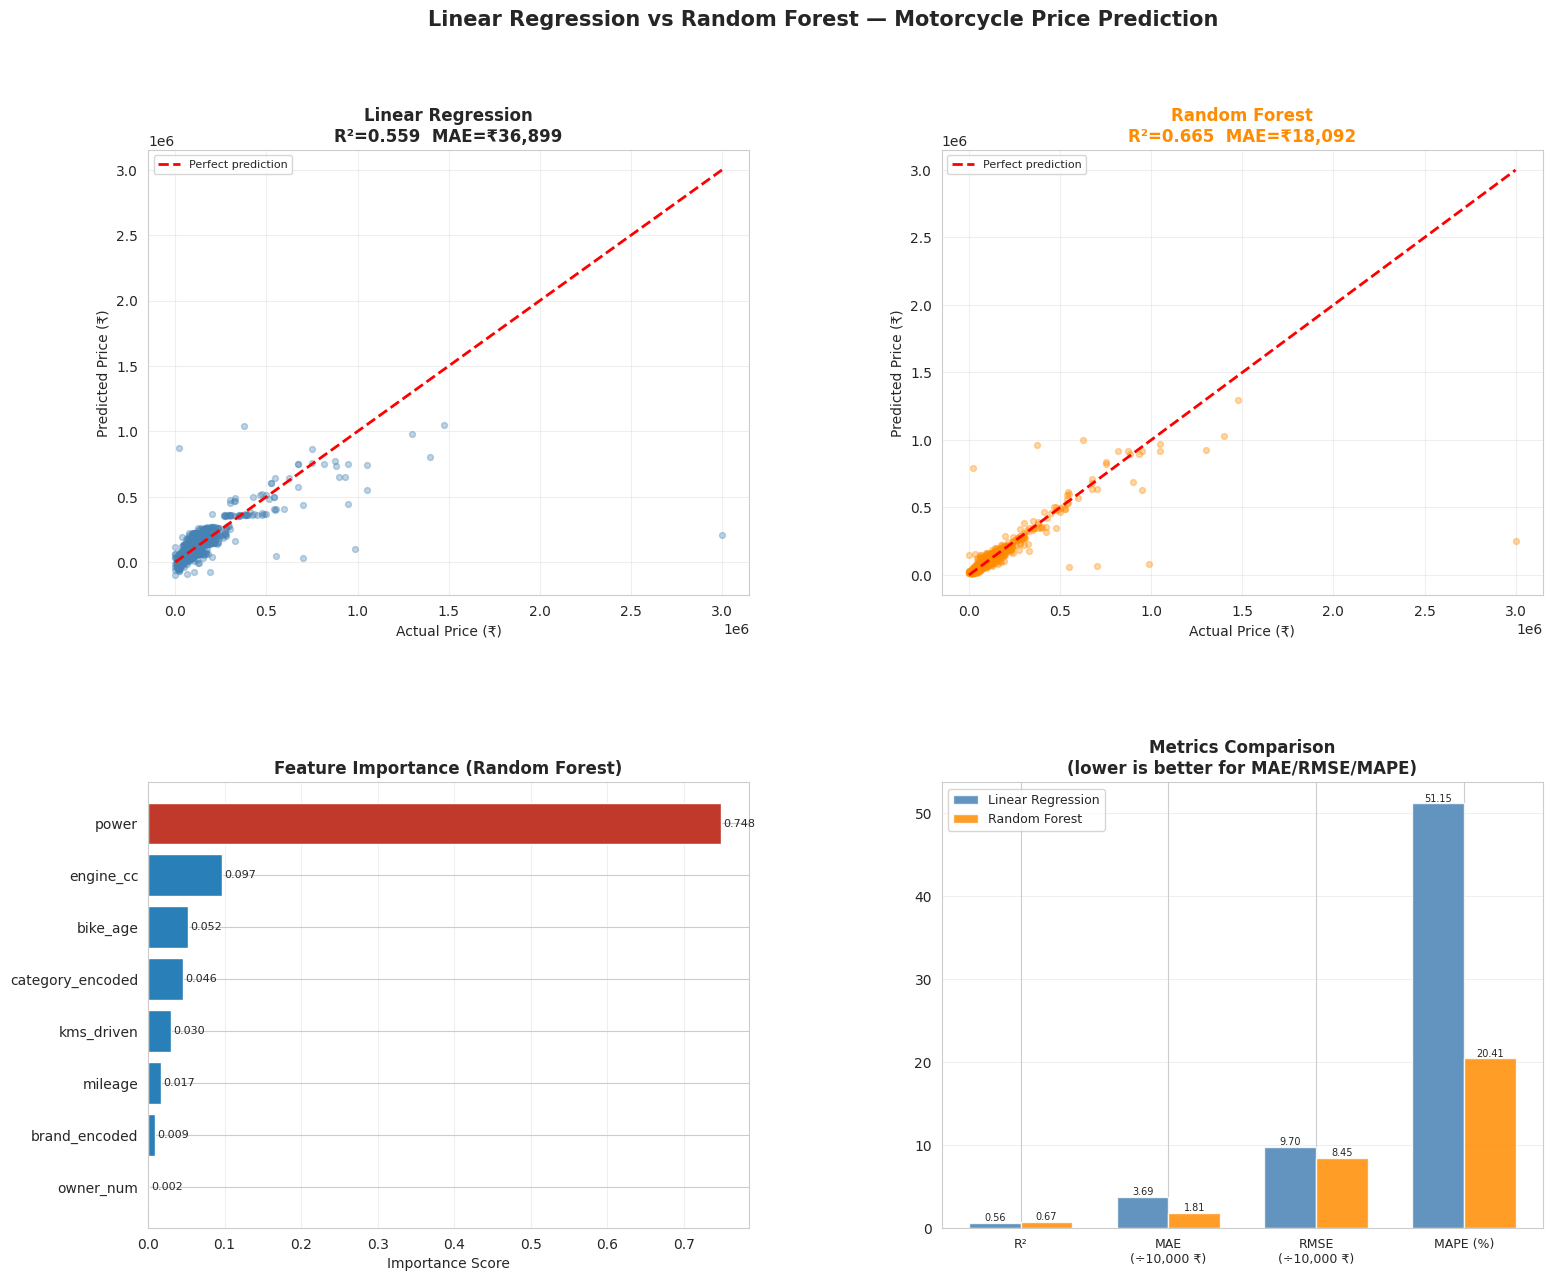

Saved: rf_vs_lr_comparison.png


In [21]:
# ============================================================================
# SECTION 10 — COMPARISON VISUALISATIONS (4-panel figure)
# ============================================================================

fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    'Linear Regression vs Random Forest — Motorcycle Price Prediction',
    fontsize=15, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# Panel 1 — LR actual vs predicted
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, lr_pred, alpha=0.35, s=18, color='steelblue')
max_val = max(y_test.max(), lr_pred.max(), rf_pred.max())
ax1.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect prediction')
ax1.set_title(f'Linear Regression\nR²={lr_r2:.3f}  MAE=₹{lr_mae:,.0f}',
              fontweight='bold')
ax1.set_xlabel('Actual Price (₹)'); ax1.set_ylabel('Predicted Price (₹)')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# Panel 2 — RF actual vs predicted
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_test, rf_pred, alpha=0.35, s=18, color='darkorange')
ax2.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect prediction')
ax2.set_title(f'Random Forest\nR²={rf_r2:.3f}  MAE=₹{rf_mae:,.0f}',
              fontweight='bold', color='darkorange')
ax2.set_xlabel('Actual Price (₹)'); ax2.set_ylabel('Predicted Price (₹)')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# Panel 3 — Feature importance
ax3 = fig.add_subplot(gs[1, 0])
bar_colors = ['#C0392B' if i == 0 else '#2980B9'
              for i in range(len(importance_df))]
hbars = ax3.barh(importance_df['Feature'], importance_df['Importance'],
                 color=bar_colors)
ax3.set_title('Feature Importance (Random Forest)', fontweight='bold')
ax3.set_xlabel('Importance Score')
ax3.invert_yaxis(); ax3.grid(axis='x', alpha=0.3)
for bar, val in zip(hbars, importance_df['Importance']):
    ax3.text(bar.get_width() + 0.003,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=8)

# Panel 4 — Metrics comparison
ax4 = fig.add_subplot(gs[1, 1])
metrics      = ['R²', 'MAE\n(÷10,000 ₹)', 'RMSE\n(÷10,000 ₹)', 'MAPE (%)']
lr_norm      = [lr_r2, lr_mae/10000, lr_rmse/10000, lr_mape]
rf_norm      = [rf_r2, rf_mae/10000, rf_rmse/10000, rf_mape]
x_pos        = np.arange(len(metrics))
width        = 0.35

bars_lr = ax4.bar(x_pos - width/2, lr_norm, width,
                  label='Linear Regression', color='steelblue',   alpha=0.85)
bars_rf = ax4.bar(x_pos + width/2, rf_norm, width,
                  label='Random Forest',     color='darkorange',   alpha=0.85)
ax4.set_xticks(x_pos); ax4.set_xticklabels(metrics, fontsize=9)
ax4.set_title('Metrics Comparison\n(lower is better for MAE/RMSE/MAPE)',
              fontweight='bold')
ax4.legend(fontsize=9); ax4.grid(axis='y', alpha=0.3)
for bar in list(bars_lr) + list(bars_rf):
    h = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, h + 0.01,
             f'{h:.2f}', ha='center', va='bottom', fontsize=7)

plt.savefig('rf_vs_lr_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: rf_vs_lr_comparison.png")


In [22]:
# ============================================================================
# SECTION 11 — KEY FINDINGS SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)

top_f  = importance_df.iloc[0]
sec_f  = importance_df.iloc[1]
depr   = abs(z[0])
f1_med = owner_stats.loc[1, 'median']
f2_med = owner_stats.loc[2, 'median']
prem   = (f1_med - f2_med) / f1_med * 100
p25    = data['price'].quantile(0.25)
p75    = data['price'].quantile(0.75)

print(f"""
1. MODEL IMPROVEMENT
   LR  → RF:  R² {lr_r2:.3f} → {rf_r2:.3f}  (+{r2_gain:.1f}%)
              MAE ₹{lr_mae:,.0f} → ₹{rf_mae:,.0f}  (-{mae_drop:.1f}%)
              MAPE {lr_mape:.1f}% → {rf_mape:.1f}%

2. TOP PRICE DRIVER
   {top_f['Feature']} accounts for {top_f['Importance']*100:.1f}% of the model's prediction power
   Second: {sec_f['Feature']} at {sec_f['Importance']*100:.1f}%

3. PRICE DISTRIBUTION
   Median ₹{data['price'].median():,.0f}  vs  Mean ₹{data['price'].mean():,.0f}  — right-skewed
   50% of bikes priced between ₹{p25:,.0f} and ₹{p75:,.0f}

4. FIRST-OWNER PREMIUM
   ₹{f1_med:,.0f} (1st) vs ₹{f2_med:,.0f} (2nd) — {prem:.1f}% premium

5. DEPRECIATION RATE
   ₹{depr:,.0f} per year on average (bikes aged 1–20 years)

6. MARKET SEGMENTATION
   Economy: {(data['brand_category']=='Economy').sum()/len(data)*100:.1f}% of listings
   Premium avg price is {data[data['brand_category']=='Premium']['price'].mean() / data[data['brand_category']=='Economy']['price'].mean():.1f}x the Economy avg
""")

# Save cleaned data for the SQL project
data.to_csv('bikes_cleaned.csv', index=False)
print("Cleaned data saved to bikes_cleaned.csv")
print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)




KEY FINDINGS

1. MODEL IMPROVEMENT
   LR  → RF:  R² 0.559 → 0.665  (+19.1%)
              MAE ₹36,899 → ₹18,092  (-51.0%)
              MAPE 51.2% → 20.4%

2. TOP PRICE DRIVER
   power accounts for 74.8% of the model's prediction power
   Second: engine_cc at 9.7%

3. PRICE DISTRIBUTION
   Median ₹75,000  vs  Mean ₹106,791  — right-skewed
   50% of bikes priced between ₹42,000 and ₹125,000

4. FIRST-OWNER PREMIUM
   ₹78,000 (1st) vs ₹62,800 (2nd) — 19.5% premium

5. DEPRECIATION RATE
   ₹10,933 per year on average (bikes aged 1–20 years)

6. MARKET SEGMENTATION
   Economy: 63.8% of listings
   Premium avg price is 9.5x the Economy avg

Cleaned data saved to bikes_cleaned.csv

ANALYSIS COMPLETE
